# 02 · The model, end to end on one city

This notebook runs the actual pipeline code for London at the two-days-out decision (noon local, lead 3): point-in-time features from the forecast archive, the walk-forward EMOS fit, calibration, and the comparison with market prices on the days the model disagrees with the market. It takes a few minutes; everything it prints is what `python -m weather_edge model --stations EGLC --leads 3` writes to `reports/`.

Two rules are enforced inside the functions used here: a run counts only if every one of its steps inside the local day was public (Last-Modified) before the decision, and each day's fit sees only labels of days that had ended by the decision.

In [1]:
import os, json
os.chdir(next(p for p in [os.getcwd(), os.path.dirname(os.getcwd())] if os.path.exists(os.path.join(p, "pyproject.toml"))))
import duckdb, numpy as np, pandas as pd, matplotlib.pyplot as plt
from weather_edge import plots
from weather_edge.plots import read_tables, SERIES, INK, INK_2, GRID, SURFACE
%matplotlib inline
plt.rcParams.update({"figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "axes.edgecolor": GRID, "axes.grid": True, "grid.color": GRID, "axes.spines.top": False, "axes.spines.right": False, "axes.titlelocation": "left", "figure.dpi": 110})
pd.set_option("display.width", 160)
from weather_edge import model as m
from weather_edge.market_checks import STATION_TZ
con = duckdb.connect("data/research.duckdb", read_only=True); con.execute("SET enable_progress_bar=false")
con.execute("ATTACH 'data/prices.duckdb' AS px (READ_ONLY)"); con.execute("ATTACH 'data/forecasts.duckdb' AS fc (READ_ONLY)")
STATION, TZ = "EGLC", STATION_TZ["EGLC"]

## Features at the decision time

One row per day and lead: the latest public run of each model and its maximum over the steps inside the local day (°C), the ensemble spread at that step, and the decision time `t` (UTC).

In [2]:
feats = m.features(con, STATION, TZ, 12)
lead3 = feats[feats.lead == 3]
print(len(feats), "rows;", lead3.day.min().date(), "to", lead3.day.max().date())
lead3[["day", "t", "ecmwf", "gfs", "gefs_mean", "gefs_spread"]].tail(5)

1911 rows; 2025-01-03 to 2026-09-30


,day,t,ecmwf,gfs,gefs_mean,gefs_spread
1898,2026-09-26,2026-09-24 11:00:00,20.408600,20.860172,20.19952,1.17800
1901,2026-09-27,2026-09-25 11:00:00,22.639415,23.235909,21.84132,1.20000
1904,2026-09-28,2026-09-26 11:00:00,18.858283,17.932231,17.45308,1.95444
1907,2026-09-29,2026-09-27 11:00:00,24.716923,20.231760,22.06288,1.60000
1910,2026-09-30,2026-09-28 11:00:00,22.325132,20.948240,20.64376,1.30200


The publication-time rule in action: at noon two days before the day, the newest ECMWF run that fully covers the day is the 06Z run of that morning (public about 12:30 UTC), never the 12Z run.

In [3]:
runs = con.execute("""
SELECT model, init_time, max(available_time) AS public_at FROM fc.forecasts
WHERE station = ? AND init_time >= TIMESTAMP '2026-07-28' AND init_time < TIMESTAMP '2026-07-29' AND lead_h <= 60
GROUP BY 1, 2 ORDER BY 1, 2""", [STATION]).df()
runs

,model,init_time,public_at
0,ecmwf,2026-07-28 00:00:00,2026-07-28 07:34:38
1,ecmwf,2026-07-28 06:00:00,2026-07-28 12:28:36
2,ecmwf,2026-07-28 12:00:00,2026-07-28 19:34:39
3,ecmwf,2026-07-28 18:00:00,2026-07-29 00:27:36
4,gefs_mean,2026-07-28 00:00:00,2026-07-28 04:17:12
5,gefs_mean,2026-07-28 06:00:00,2026-07-28 10:13:40
6,gefs_mean,2026-07-28 12:00:00,2026-07-28 16:19:50
7,gefs_mean,2026-07-28 18:00:00,2026-07-28 22:15:11
8,gefs_spread,2026-07-28 00:00:00,2026-07-28 04:17:12
9,gefs_spread,2026-07-28 06:00:00,2026-07-28 10:13:39


## Walk-forward fit and scores

`run_station` fits the t-EMOS on a trailing 90-day window every day, rescales its spread with the last 90 out-of-sample errors, and scores against climatology, the raw multi-model mean and the market. Days before 2026-08-01 only; the holdout stays untouched here.

In [4]:
r = m.run_station(con, STATION, 12, leads=[3])
display(r["coverage"]); display(r["continuous"]); r["market"]

,station,decision_hour_local,period,feature_days,label_days,sources_with_coverage,obs_days,share_max_before_decision,market_buckets
0,EGLC,12,before 2026-08-01,577,577,"[ecmwf, gfs, gefs_mean, gefs_spread]",577,NaN,3118


,lead,model,days,crps,mae,mean_sigma,median_nu,pit_bins,coverage_90
0,3,clim,565,2.278179,3.148022,3.306519,NaN,"[0.21, 0.18, 0.16, 0.17, 0.28]",0.812389
1,3,raw,574,0.894780,1.237805,2.174049,NaN,"[0.04, 0.1, 0.26, 0.4, 0.21]",0.982578
2,3,emos,552,0.744755,0.985798,1.342142,7.545277,"[0.2, 0.25, 0.25, 0.2, 0.1]",0.923913


,lead,model,buckets,days,brier_market,brier_model,logloss_market,logloss_model,n_disagree,market_minus_model_on_disagree,ci_low,ci_high
0,3,clim,3118,365,0.101930,0.130159,0.318637,0.470531,1723,-0.049785,-0.060279,-0.038991
1,3,raw,3111,364,0.101886,0.095701,0.318461,0.318222,1338,0.018019,0.008938,0.027060
2,3,emos,3111,364,0.101886,0.087667,0.318461,0.289384,1087,0.042342,0.031264,0.052517


## Is the predictive distribution honest?

The probability integral transform of the realised maximum under the model's distribution should be flat. The 90% interval should cover about 90% of days.

90% interval coverage: 0.924 | mean calibration scale: 1.36


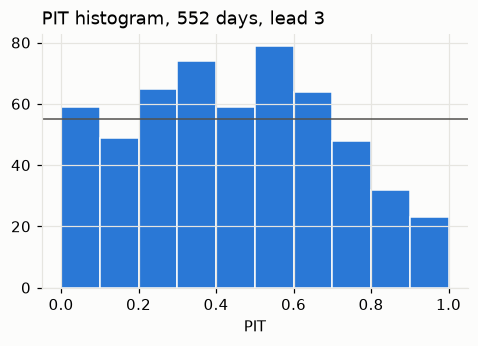

In [5]:
wf = r["wf"].dropna(subset=["emos_mu", "y"])
pit = np.array([m.cdf(row.y, row.emos_mu, row.emos_sigma, row.emos_nu)[()] for row in wf.itertuples()])
fig, ax = plt.subplots(figsize=(5, 3))
ax.hist(pit, bins=10, range=(0, 1), color=SERIES[0], edgecolor=SURFACE)
ax.axhline(len(pit) / 10, color=INK_2, lw=1); ax.set_title(f"PIT histogram, {len(pit)} days, lead 3"); ax.set_xlabel("PIT")
lo = np.array([m.ppf(0.05, a, b, c) for a, b, c in zip(wf.emos_mu, wf.emos_sigma, wf.emos_nu)])
hi = np.array([m.ppf(0.95, a, b, c) for a, b, c in zip(wf.emos_mu, wf.emos_sigma, wf.emos_nu)])
print("90% interval coverage:", round(float(((wf.y >= lo) & (wf.y <= hi)).mean()), 3), "| mean calibration scale:", round(float(wf.emos_scale.mean()), 2))

## Reliability: model probabilities against market prices

Every resolved bucket with a price at the decision, binned by the model's probability and by the market's price. Both are honest; the model's bins are wider apart on the disagreement buckets, which is where it wins two days out.

disagreement buckets: 1087 of 3111; Brier market 0.1772 vs model 0.1348


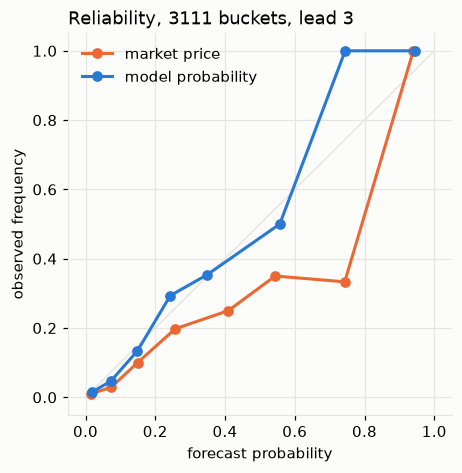

In [6]:
sc = r["scored"].dropna(subset=["p_emos"])
bins = np.array([0, 0.05, 0.1, 0.2, 0.3, 0.5, 0.7, 0.9, 1.0])
def reliability(p):
    g = sc.groupby(pd.cut(p, bins), observed=True)
    return pd.DataFrame({"mean_p": g.apply(lambda d: p.loc[d.index].mean()), "hit_rate": g.outcome.mean(), "n": g.size()})
model_rel, market_rel = reliability(sc.p_emos), reliability(sc.market_p)
fig, ax = plt.subplots(figsize=(4.5, 4.5))
ax.plot([0, 1], [0, 1], color=GRID, lw=1)
ax.plot(market_rel.mean_p, market_rel.hit_rate, color=SERIES[1], lw=2, marker="o", label="market price")
ax.plot(model_rel.mean_p, model_rel.hit_rate, color=SERIES[0], lw=2, marker="o", label="model probability")
ax.set_xlabel("forecast probability"); ax.set_ylabel("observed frequency"); ax.set_title(f"Reliability, {len(sc)} buckets, lead 3"); ax.legend(frameon=False)
dis = sc[(sc.p_emos - sc.market_p).abs() >= 0.10]
print(f"disagreement buckets: {len(dis)} of {len(sc)}; Brier market {((dis.market_p - dis.outcome) ** 2).mean():.4f} vs model {((dis.p_emos - dis.outcome) ** 2).mean():.4f}")
con.close()